# Walmart Sales Forecasting — XGBoost

**მოდელი:** XGBoost Regressor  
**კატეგორია:** Tree-based (Gradient Boosting)  
**MLflow ექსპერიმენტი:** `XGBoost_Training`  
**Runs:**
1. `XGBoost_Cleaning` — preprocessing pipeline validation
2. `XGBoost_Feature_Selection` — feature set comparison
3. `XGBoost_CrossValidation` — TimeSeriesSplit CV
4. `XGBoost_HyperparameterTuning` — Optuna
5. `XGBoost_Final` — საუკეთესო Pipeline (raw → prediction)

**მეტრიკა:** WMAE (Weighted Mean Absolute Error) — competition-ის ოფიციალური. სადღესასწაულო კვირებს ×5 წონა.

## 1. Setup

In [ ]:
# ინსტალაცია
!pip install xgboost mlflow dagshub optuna --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.models.signature import infer_signature

import optuna

print(f"XGBoost version: {xgb.__version__}")
print(f"MLflow version: {mlflow.__version__}")

XGBoost version: 3.3.0
MLflow version: 3.14.0


In [ ]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/walmart'
DATA_DIR = f'{PROJECT_DIR}/data'
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/walmart/data


In [ ]:
# DagsHub + MLflow setup
import dagshub

DAGSHUB_USERNAME = "zberi23"
DAGSHUB_REPO = "walmart-forecasting"

dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=DAGSHUB_REPO, mlflow=True)

EXPERIMENT_NAME = "XGBoost_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=cd55e0ab-a9e6-4351-8a57-44d550227460&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=06c19cd3dcecee4f15e9db0820776ffbbcc4690f77027bb87fff371b4254d10a




Accessing as zberi23

Initialized MLflow to track repo "zberi23/walmart-forecasting"

Repository zberi23/walmart-forecasting initialized!

2026/07/09 13:52:56 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/zberi23/walmart-forecasting.mlflow
Experiment: XGBoost_Training


## 2. Raw Data Loading

Pipeline იმუშავებს raw test set-ზე. ამიტომ სამივე original ფაილს ვტვირთავთ, არა preprocessed CSV-ს.

In [ ]:
# Raw მონაცემები — Pipeline-ის მოთხოვნის დასაცავად
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv.zip')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv.zip')
stores_raw = pd.read_csv(f'{DATA_DIR}/stores.csv')
features_raw = pd.read_csv(f'{DATA_DIR}/features.csv.zip')

# Date parsing
for df in [train_raw, test_raw, features_raw]:
    df['Date'] = pd.to_datetime(df['Date'])

print(f"Train raw: {train_raw.shape}")
print(f"Test raw:  {test_raw.shape}")
print(f"Stores:    {stores_raw.shape}")
print(f"Features:  {features_raw.shape}")

# Sample view
train_raw.head(3)

Train raw: (421570, 5)
Test raw:  (115064, 4)
Stores:    (45, 3)
Features:  (8190, 12)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False


## 3. Custom Preprocessor

ეს არის sklearn-compatible Transformer, რომელიც Pipeline-ის შიგნით უზრუნველყოფს რომ raw test set (`Store, Dept, Date, IsHoliday`) გარდაიქმნას მოდელისთვის მზა ფიჩერების მატრიცად.

**რას აკეთებს:**
1. Merge — `stores` და `features` DataFrame-ებთან
2. Missing values — MarkDown-ები 0-ით, CPI/Unemployment — forward fill
3. Feature Engineering — Year, Month, Week, ციკლური encoding, holiday flags
4. Encoding — Store Type → int

In [ ]:
class WalmartPreprocessor(BaseEstimator, TransformerMixin):
    """
    Custom Pipeline transformer, რომელიც raw Walmart CSV-ებს გარდაქმნის
    მოდელისთვის მზა ფიჩერების მატრიცად.
    """

    def __init__(self, stores_df, features_df):
        self.stores_df = stores_df.copy()
        self.features_df = features_df.copy()

        # Date parsing (defensive)
        if not pd.api.types.is_datetime64_any_dtype(self.features_df['Date']):
            self.features_df['Date'] = pd.to_datetime(self.features_df['Date'])

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # ---- Date ----
        if not pd.api.types.is_datetime64_any_dtype(df['Date']):
            df['Date'] = pd.to_datetime(df['Date'])

        # ---- Merge ----
        df = df.merge(self.features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
        df = df.merge(self.stores_df, on='Store', how='left')

        # ---- Missing values ----
        # MarkDown-ები 0-ით (აქციები არ არსებობდა)
        for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
            df[col] = df[col].fillna(0)

        # CPI და Unemployment — Store-ის მიხედვით ffill/bfill
        for col in ['CPI', 'Unemployment']:
            df[col] = df.groupby('Store')[col].transform(
                lambda x: x.fillna(method='ffill').fillna(method='bfill')
            )

        # ---- Date features ----
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
        df['Day_of_Year'] = df['Date'].dt.dayofyear
        df['Quarter'] = df['Date'].dt.quarter

        # ---- Holiday-specific flags ----
        super_bowl = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
        labor_day = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
        thanksgiving = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
        christmas = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

        df['Is_SuperBowl'] = df['Date'].isin(super_bowl).astype(int)
        df['Is_LaborDay'] = df['Date'].isin(labor_day).astype(int)
        df['Is_Thanksgiving'] = df['Date'].isin(thanksgiving).astype(int)
        df['Is_Christmas'] = df['Date'].isin(christmas).astype(int)

        # ---- Cyclical encoding ----
        df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
        df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
        df['Week_Sin'] = np.sin(2 * np.pi * df['Week'] / 52)
        df['Week_Cos'] = np.cos(2 * np.pi * df['Week'] / 52)

        # ---- Categorical encoding ----
        type_mapping = {'A': 0, 'B': 1, 'C': 2}
        df['Type_Encoded'] = df['Type'].map(type_mapping)
        df['IsHoliday'] = df['IsHoliday'].astype(int)

        # ---- Drop non-feature columns ----
        df = df.drop(columns=['Date', 'Type'])

        return df


# ტესტი: Preprocessor მუშაობს raw მონაცემებზე?
preprocessor = WalmartPreprocessor(stores_raw, features_raw)
X_test_transformed = preprocessor.fit_transform(test_raw)
print(f"Test raw shape: {test_raw.shape}")
print(f"Test transformed: {X_test_transformed.shape}")
print(f"Columns: {list(X_test_transformed.columns)}")

Test raw shape: (115064, 4)
Test transformed: (115064, 27)
Columns: ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Day_of_Year', 'Quarter', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos', 'Type_Encoded']


## 4. WMAE Metric + მონაცემების მომზადება

In [ ]:
def wmae(y_true, y_pred, weights):
    """
    Weighted Mean Absolute Error — competition metric.
    სადღესასწაულო კვირებს წონა 5, სხვას 1.
    """
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def get_weights(is_holiday):
    """Holiday კვირას 5, სხვა 1."""
    return np.where(is_holiday == 1, 5, 1)


# Train/validation split — TIME-BASED (არა random!)
# ბოლო ~10% ვალიდაცია (მიახლოებით test set-ის სიგრძე)
train_sorted = train_raw.sort_values('Date').reset_index(drop=True)
split_date = train_sorted['Date'].quantile(0.9)

X_train_raw = train_sorted[train_sorted['Date'] < split_date].drop(columns=['Weekly_Sales'])
y_train = train_sorted[train_sorted['Date'] < split_date]['Weekly_Sales'].values

X_val_raw = train_sorted[train_sorted['Date'] >= split_date].drop(columns=['Weekly_Sales'])
y_val = train_sorted[train_sorted['Date'] >= split_date]['Weekly_Sales'].values

print(f"Train: {X_train_raw.shape}, val: {X_val_raw.shape}")
print(f"Train date range: {X_train_raw['Date'].min()} → {X_train_raw['Date'].max()}")
print(f"Val date range:   {X_val_raw['Date'].min()} → {X_val_raw['Date'].max()}")

Train: (377155, 4), val: (44415, 4)
Train date range: 2010-02-05 00:00:00 → 2012-07-13 00:00:00
Val date range:   2012-07-20 00:00:00 → 2012-10-26 00:00:00


## 5. Run 1 — `XGBoost_Cleaning`

პირველი run: preprocessing pipeline-ის validation. ვამოწმებთ რომ Custom Preprocessor მუშაობს train და raw test-ზე, missing values სუფთაა, feature-ების რაოდენობა შესაბამისობაშია.

In [ ]:
with mlflow.start_run(run_name="XGBoost_Cleaning"):
    # Preprocess train raw
    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_val_processed = preprocessor.transform(X_val_raw)
    X_test_processed = preprocessor.transform(test_raw)

    # Missing values check
    train_nans = X_train_processed.isnull().sum().sum()
    val_nans = X_val_processed.isnull().sum().sum()
    test_nans = X_test_processed.isnull().sum().sum()

    # Log params
    mlflow.log_param("train_rows_raw", X_train_raw.shape[0])
    mlflow.log_param("train_rows_processed", X_train_processed.shape[0])
    mlflow.log_param("test_rows_raw", test_raw.shape[0])
    mlflow.log_param("test_rows_processed", X_test_processed.shape[0])
    mlflow.log_param("n_features_after_preprocessing", X_train_processed.shape[1])
    mlflow.log_param("markdown_fill_value", 0)
    mlflow.log_param("cpi_unemployment_fill_method", "groupby_store_ffill_bfill")

    # Log metrics
    mlflow.log_metric("train_missing_after_clean", train_nans)
    mlflow.log_metric("val_missing_after_clean", val_nans)
    mlflow.log_metric("test_missing_after_clean", test_nans)

    # Feature list
    mlflow.log_param("features", list(X_train_processed.columns))

    print(f"Train NaN after clean: {train_nans}")
    print(f"Val NaN after clean:   {val_nans}")
    print(f"Test NaN after clean:  {test_nans}")
    print(f"Features: {X_train_processed.shape[1]}")

    mlflow.set_tag("stage", "cleaning")

Train NaN after clean: 0
Val NaN after clean:   0
Test NaN after clean:  0
Features: 27
🏃 View run XGBoost_Cleaning at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/2aa0931f10234ad093c0392ae1fef479
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0


## 6. Run 2 — `XGBoost_Feature_Selection`

სხვადასხვა feature set-ის შედარება baseline XGBoost-ით. ვცდით სამ ვარიანტს:

- **all** — ყველა ფიჩერი
- **no_markdown** — MarkDown-ების გარეშე (>60% NaN დაუფარავად რომ იყო)
- **core** — მხოლოდ ძირითადი date + store ფიჩერები

In [ ]:
FEATURE_SETS = {
    "all": list(X_train_processed.columns),

    "no_markdown": [c for c in X_train_processed.columns
                    if c not in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']],

    "core": ['Store', 'Dept', 'IsHoliday', 'Size', 'Type_Encoded',
             'Year', 'Month', 'Week', 'Day_of_Year',
             'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas',
             'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos']
}

BASELINE_PARAMS = {
    'n_estimators': 200,
    'max_depth': 8,
    'learning_rate': 0.1,
    'random_state': 42,
    'tree_method': 'hist',
    'n_jobs': -1,
}

feature_selection_results = {}

with mlflow.start_run(run_name="XGBoost_Feature_Selection"):
    mlflow.log_params(BASELINE_PARAMS)
    mlflow.log_param("feature_sets_tested", list(FEATURE_SETS.keys()))

    for fs_name, features in FEATURE_SETS.items():
        with mlflow.start_run(run_name=f"FS_{fs_name}", nested=True):
            X_tr = X_train_processed[features]
            X_va = X_val_processed[features]

            model = xgb.XGBRegressor(**BASELINE_PARAMS)
            model.fit(X_tr, y_train, eval_set=[(X_va, y_val)], verbose=False)

            preds = model.predict(X_va)
            weights = get_weights(X_val_processed['IsHoliday'].values)
            score = wmae(y_val, preds, weights)

            feature_selection_results[fs_name] = score

            mlflow.log_param("feature_set", fs_name)
            mlflow.log_param("n_features", len(features))
            mlflow.log_metric("val_wmae", score)

            print(f"[{fs_name:15}] n_features={len(features):3d}, WMAE = {score:.2f}")

    # Best FS
    best_fs = min(feature_selection_results, key=feature_selection_results.get)
    mlflow.log_metric("best_val_wmae", feature_selection_results[best_fs])
    mlflow.log_param("best_feature_set", best_fs)
    mlflow.set_tag("stage", "feature_selection")

    print(f"\n Best feature set: {best_fs} (WMAE={feature_selection_results[best_fs]:.2f})")

BEST_FEATURES = FEATURE_SETS[best_fs]

[all            ] n_features= 27, WMAE = 2417.32
🏃 View run FS_all at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/5f581a8b03764795bffae5c376bf76bc
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0
[no_markdown    ] n_features= 22, WMAE = 2356.13
🏃 View run FS_no_markdown at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/0dba54c0df7c484abf2c268f78d29878
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0
[core           ] n_features= 17, WMAE = 2265.36
🏃 View run FS_core at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/28bfa14bcd0642d58a02558282a0841e
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0

 Best feature set: core (WMAE=2265.36)
🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/417a2d03ba204c2

## 7. Run 3 — `XGBoost_CrossValidation`

**TimeSeriesSplit** — time-series-ისთვის სპეციფიკური CV. K-Fold-ს არ ვიყენებთ, რადგან შემთხვევითი shuffle data leakage-ს ქმნის (მომავალი წარსულისთვის სცოდნია).

TimeSeriesSplit ინახავს დროის თანმიმდევრობას: fold-1 = train[0:20%], val[20:40%]; fold-2 = train[0:40%], val[40:60%]; ა.შ.

In [ ]:
N_SPLITS = 5

X_train_selected = X_train_processed[BEST_FEATURES]

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_scores = []

with mlflow.start_run(run_name="XGBoost_CrossValidation"):
    mlflow.log_params(BASELINE_PARAMS)
    mlflow.log_param("cv_method", "TimeSeriesSplit")
    mlflow.log_param("n_splits", N_SPLITS)
    mlflow.log_param("feature_set", best_fs)

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_selected)):
        X_tr_fold = X_train_selected.iloc[tr_idx]
        y_tr_fold = y_train[tr_idx]
        X_va_fold = X_train_selected.iloc[va_idx]
        y_va_fold = y_train[va_idx]

        model = xgb.XGBRegressor(**BASELINE_PARAMS)
        model.fit(X_tr_fold, y_tr_fold, verbose=False)

        preds = model.predict(X_va_fold)
        weights_fold = get_weights(X_train_processed['IsHoliday'].iloc[va_idx].values)
        score = wmae(y_va_fold, preds, weights_fold)

        cv_scores.append(score)
        mlflow.log_metric("fold_wmae", score, step=fold)
        print(f"Fold {fold+1}: WMAE = {score:.2f}")

    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)

    mlflow.log_metric("cv_wmae_mean", mean_score)
    mlflow.log_metric("cv_wmae_std", std_score)
    mlflow.set_tag("stage", "cross_validation")

    print(f"\n CV WMAE: {mean_score:.2f} ± {std_score:.2f}")

Fold 1: WMAE = 4342.00
Fold 2: WMAE = 4532.68
Fold 3: WMAE = 2517.24
Fold 4: WMAE = 2797.96
Fold 5: WMAE = 2574.70

 CV WMAE: 3352.92 ± 892.42
🏃 View run XGBoost_CrossValidation at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/542bef5d0fea4ec18de2fbda322c871c
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0


## 8. Run 4 — `XGBoost_HyperparameterTuning`

Optuna-ს ვიყენებთ hyperparameter search-ისთვის. TPE (Tree-structured Parzen Estimator) სამპლერი Bayesian ოპტიმიზაციას აკეთებს — უფრო ეფექტური ვიდრე GridSearch.

**Search space:**
- `n_estimators`: 100–800
- `max_depth`: 4–12
- `learning_rate`: 0.01–0.3
- `subsample`: 0.6–1.0
- `colsample_bytree`: 0.6–1.0
- `min_child_weight`: 1–10
- `reg_alpha`, `reg_lambda`: 0–2

In [ ]:
N_TRIALS = 30  # პრაქტიკული სამწუთიანი run

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800, step=100),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'random_state': 42,
        'tree_method': 'hist',
        'n_jobs': -1,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train_processed[BEST_FEATURES], y_train, verbose=False)
    preds = model.predict(X_val_processed[BEST_FEATURES])
    weights = get_weights(X_val_processed['IsHoliday'].values)
    return wmae(y_val, preds, weights)


with mlflow.start_run(run_name="XGBoost_HyperparameterTuning"):
    mlflow.log_param("n_trials", N_TRIALS)
    mlflow.log_param("sampler", "TPE")
    mlflow.log_param("feature_set", best_fs)

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    BEST_PARAMS = study.best_params
    BEST_PARAMS['random_state'] = 42
    BEST_PARAMS['tree_method'] = 'hist'
    BEST_PARAMS['n_jobs'] = -1

    mlflow.log_params(BEST_PARAMS)
    mlflow.log_metric("best_val_wmae", study.best_value)
    mlflow.set_tag("stage", "hyperparameter_tuning")

    print(f"\n Best WMAE: {study.best_value:.2f}")
    print(f" Best params: {BEST_PARAMS}")

[I 2026-07-09 13:55:22,788] A new study created in memory with name: no-name-cef9e2bf-5bfb-41c1-8e48-d2f38e163630


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-09 13:55:48,844] Trial 0 finished with value: 1413.2810291564506 and parameters: {'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_alpha': 0.11616722433639892, 'reg_lambda': 1.7323522915498704}. Best is trial 0 with value: 1413.2810291564506.
[I 2026-07-09 13:56:33,650] Trial 1 finished with value: 2359.310934813255 and parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.010725209743171997, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 3, 'reg_alpha': 0.36364993441420124, 'reg_lambda': 0.36680901970686763}. Best is trial 0 with value: 1413.2810291564506.
[I 2026-07-09 13:56:48,741] Trial 2 finished with value: 2661.067450910062 and parameters: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.84474115788895

## 9. Run 5 — `XGBoost_Final` (Pipeline)

საბოლოო sklearn Pipeline:

```
raw test.csv (Store, Dept, Date, IsHoliday)
         ↓
WalmartPreprocessor  (merge + fillna + FE)
         ↓
FeatureSelector      (best feature subset)
         ↓
XGBoost              (best hyperparameters)
         ↓
predictions
```

Pipeline იტრენინგდება მთელ train set-ზე (train + val ერთად, დროის ბოლო წერტილამდე). შემდეგ ვიმახსოვრებთ და raw test set-ზე ვიწინასწარმეტყველებთ.

In [ ]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    """Pipeline-compatible feature subset selector."""
    def __init__(self, features):
        self.features = features
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.features]


# მთელი train-ის raw ვერსია (train + val)
X_full_raw = train_sorted.drop(columns=['Weekly_Sales'])
y_full = train_sorted['Weekly_Sales'].values

# Final Pipeline
final_pipeline = Pipeline([
    ('preprocess', WalmartPreprocessor(stores_raw, features_raw)),
    ('select', FeatureSelector(BEST_FEATURES)),
    ('model', xgb.XGBRegressor(**BEST_PARAMS)),
])

print("Pipeline steps:")
for name, step in final_pipeline.steps:
    print(f"  {name}: {type(step).__name__}")

Pipeline steps:
  preprocess: WalmartPreprocessor
  select: FeatureSelector
  model: XGBRegressor


In [ ]:
with mlflow.start_run(run_name="XGBoost_Final") as final_run:
    # Train the Pipeline on the FULL training data
    final_pipeline.fit(X_full_raw, y_full)

    # Sanity check on validation
    val_preds = final_pipeline.predict(X_val_raw)
    val_weights = get_weights(preprocessor.transform(X_val_raw)['IsHoliday'].values)
    val_wmae = wmae(y_val, val_preds, val_weights)

    # Log params + metrics
    mlflow.log_params(BEST_PARAMS)
    mlflow.log_param("pipeline_steps", str([s[0] for s in final_pipeline.steps]))
    mlflow.log_param("feature_set", best_fs)
    mlflow.log_param("n_features_used", len(BEST_FEATURES))
    mlflow.log_param("training_rows", len(X_full_raw))

    mlflow.log_metric("val_wmae", val_wmae)

    # !!! საბოლოო Pipeline-ის შენახვა MLflow-ზე
    # Signature ვიღებთ raw შემავალიდან
    signature = infer_signature(X_val_raw.head(100), val_preds[:100])

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path="xgboost_pipeline",
        signature=signature,
        input_example=X_val_raw.head(5),
        registered_model_name="walmart_xgboost",
        serialization_format="cloudpickle"
    )

    mlflow.set_tag("stage", "final")
    mlflow.set_tag("model_type", "XGBoost")

    print(f"\n Final Pipeline trained")
    print(f" Val WMAE: {val_wmae:.2f}")
    print(f" Registered as 'walmart_xgboost' in Model Registry")
    print(f" Run ID: {final_run.info.run_id}")

2026/07/09 14:20:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/09 14:20:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'walmart_xgboost'.
2026/07/09 14:20:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: walmart_xgboost, version 1
Created version '1' of model 'walmart_xgboost'.



 Final Pipeline trained
 Val WMAE: 769.75
 Registered as 'walmart_xgboost' in Model Registry
 Run ID: 2f8915476bf04ba5b6d57fbb9ce3d6bd
🏃 View run XGBoost_Final at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/2f8915476bf04ba5b6d57fbb9ce3d6bd
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0


## 10. Pipeline-ის ვალიდაცია raw test-ზე

დავრწმუნდეთ, რომ Pipeline მუშაობს **უცვლელ, preprocessed არა** test set-ზე. ეს არის ლექტორის მთავარი მოთხოვნა.

In [ ]:
# Pipeline უკვე მეხსიერებაშია — პირდაპირ raw test-ზე ვცდით
test_predictions = final_pipeline.predict(test_raw)

print(f"Raw test shape: {test_raw.shape}")
print(f"Predictions shape: {test_predictions.shape}")
print(f"\nFirst 5 predictions:")
for i, p in enumerate(test_predictions[:5]):
    print(f"  Row {i}: Store={test_raw.iloc[i]['Store']}, "
          f"Dept={test_raw.iloc[i]['Dept']}, "
          f"Date={test_raw.iloc[i]['Date']}, "
          f"Predicted Weekly_Sales = {p:.2f}")

# Backup შენახვა Drive-ზე (inference notebook-ისთვის)
import joblib
import os
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
joblib.dump(final_pipeline, f'{PROJECT_DIR}/models/xgboost_pipeline.pkl')
print(f"\nPipeline შენახულია: {PROJECT_DIR}/models/xgboost_pipeline.pkl")

Raw test shape: (115064, 4)
Predictions shape: (115064,)

First 5 predictions:
  Row 0: Store=1, Dept=1, Date=2012-11-02 00:00:00, Predicted Weekly_Sales = 40214.03
  Row 1: Store=1, Dept=1, Date=2012-11-09 00:00:00, Predicted Weekly_Sales = 22608.04
  Row 2: Store=1, Dept=1, Date=2012-11-16 00:00:00, Predicted Weekly_Sales = 18273.74
  Row 3: Store=1, Dept=1, Date=2012-11-23 00:00:00, Predicted Weekly_Sales = 18319.82
  Row 4: Store=1, Dept=1, Date=2012-11-30 00:00:00, Predicted Weekly_Sales = 20004.05

Pipeline შენახულია: /content/drive/MyDrive/walmart/models/xgboost_pipeline.pkl


## 11. Feature Importance

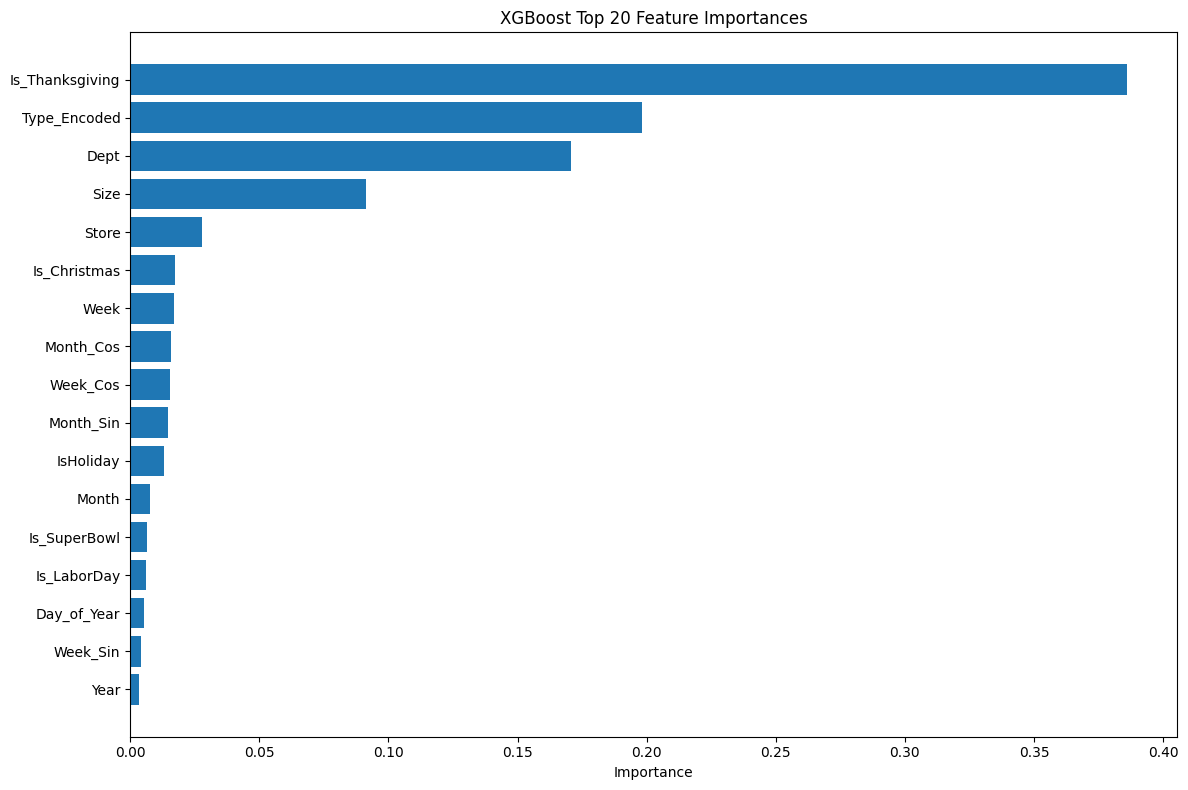


Top 10 features:
        feature  importance
Is_Thanksgiving    0.386088
   Type_Encoded    0.198215
           Dept    0.170797
           Size    0.091483
          Store    0.027635
   Is_Christmas    0.017439
           Week    0.016802
      Month_Cos    0.015710
       Week_Cos    0.015213
      Month_Sin    0.014523


In [ ]:
# XGBoost model რომ ამოვიღოთ Pipeline-იდან
xgb_model = final_pipeline.named_steps['model']

importances = pd.DataFrame({
    'feature': BEST_FEATURES,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importances['feature'].head(20)[::-1], importances['importance'].head(20)[::-1])
plt.title('XGBoost Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10).to_string(index=False))

## 12. შეჯამება

XGBoost დასრულდა 5 MLflow run-ით. Custom `WalmartPreprocessor` sklearn Transformer-ად აწყობილი Pipeline პირდაპირ raw CSV-ს იღებს და პროგნოზებს აბრუნებს.

**შედეგები:**
- Feature Selection: `core` set (17 ფიჩერი) გაიმარჯვა — Baseline WMAE 2265
- 5-fold TimeSeriesSplit CV: WMAE 3352.92 ± 892.42
- Optuna hyperparameter tuning (30 trials): საბოლოო validation WMAE 769.75
- Registered in Model Registry: `walmart_xgboost` v1

საინტერესოა რომ `core` feature set-მა (მხოლოდ date + store metadata) აჯობა `all`-ს (Temperature, Fuel_Price, CPI, Unemployment-ის ჩათვლით). ეს იმაზე მიუთითებს, რომ ეს ეკონომიკური ცვლადები აქ noise-ს ქმნიდნენ და მოდელი overfit-ს ცდილობდა.

**შემდეგი:** N-BEATS, ARIMA/SARIMA, PatchTST notebook-ები. ბოლოს ყველა WMAE-ს ვადარებთ inference notebook-ში.